In [ ]:
%load_ext autoreload
%autoreload 2
    
%matplotlib widget
import matplotlib.pyplot as plt
    
# try:
#     import cupy as xp
#     import numpy as np
#     print('Cupy assinged to xp')
# except:
#     import numpy as xp
#     print('Nupy assinged to xp')
import numpy as xp
print('Nupy assinged to xp')

Nupy assinged to xp


# Simple Build 1D (thin lens+drift)

In [2]:
from rayTEM.elements import Drift1D, Lens1D
from rayTEM.assemblies import MicroscopeSection1D

## build

In [3]:
drift0 = Drift1D(name='drift0', length=1)
lens1 = Lens1D(name='lens1', strength=1, length=0)
drift1 = Drift1D(name='drift1', length=2)
lens2 = Lens1D(name='lens2', strength=1, length=0)
drift2 = Drift1D(name='drift2', length=4)

section1 = MicroscopeSection1D(name='Section1',
                               elements=[
                                   drift0,
                                   lens1, drift1,
                                   lens2, drift2
                               ])
section1

,name,kind,length,strength,calibration
0,drift0,drift,1,0,1.0
1,lens1,Thin Lens,0,1,NaN
2,drift1,drift,2,0,1.0
3,lens2,Thin Lens,0,1,NaN
4,drift2,drift,4,0,1.0


In [5]:
list(ri)

[array([[ 1.,  0.],
        [ 1., -1.],
        [-1.,  0.],
        [-1.,  0.]]),
 array([[-1.,  0.],
        [-1.,  1.],
        [ 1.,  0.],
        [ 1.,  0.]]),
 array([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.]])]

ri (3, 4, 2)


TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

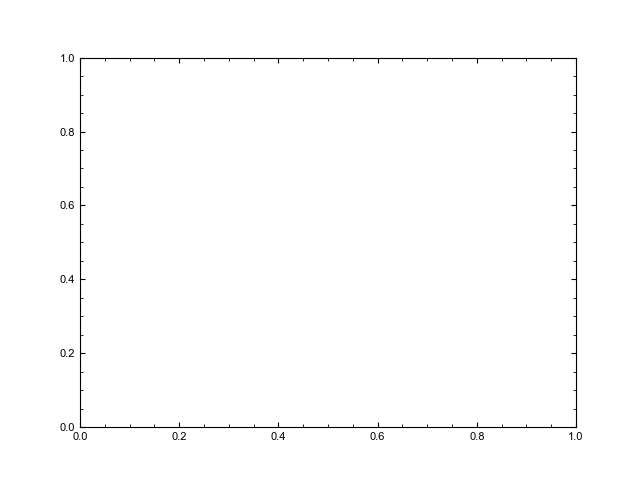

In [4]:
r0 = xp.array([[1,0],
               [-1,0],
               [0,0]])

ri = section1.propogate_ray(r0,
                            z=None#20
                           )
print('ri',ri.shape)

cs = ['k','r','b']
fig, ax = plt.subplots()
for i, path in enumerate(ri):
    ax.plot(path[...,0], ls='-',  c=cs[i], marker='.', label=f'Position ray {i}')
    ax.plot(path[...,1], ls='--', c=cs[i], marker='.', label=f'Angle ray {i}')
fig.legend(ncols=3, loc='upper center')


# Single elements

## Thin lens then manual Drift

In [6]:
from rayTEM.elements import Lens1D, Drift1D

In [7]:
lens = Lens1D(name='ThinLens', length=0, strength=1)
drift = Drift1D(length=2.)

lens, drift

,name,kind,length,strength,calibration
0,ThinLens,Thin Lens,0,1,None


,name,kind,length,strength,calibration
0,,drift,2.0,0,1


(, )

In [8]:
r0 = xp.array([[1,0],
               [-1,0],
               [0,0]])
print('r0',r0.shape)

r0 (3, 2)


c:\users\e81\documents\github\raytem\rayTEM\elements.py:306: UserWarning: z was provided for a zero length element and will not be used.
  if z is not None: warn('z was provided for a zero length element and will not be used.')


r_lens: (3, 1, 2)
[[ 1. -1.]
 [-1.  1.]
 [ 0.  0.]]
ri_drift:  (3, 20, 2)


TypeError: Implicit conversion to a NumPy array is not allowed. Please use `.get()` to construct a NumPy array explicitly.

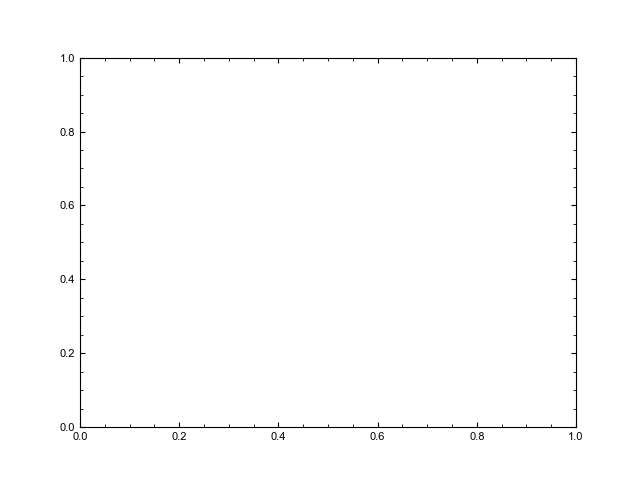

In [9]:
ri = lens.propogate_ray(r0, z=20)
print('r_lens:',ri.shape)
print(ri.squeeze())

z = 20#xp.arange(0,2)
ri2 = drift.propogate_ray(ri[:,-1], z=z)
print('ri_drift: ',ri2.shape)

fig, ax = plt.subplots()
for path in ri2[...,0]:
    ax.plot(xp.linspace(0,drift.length, z), path, ls='-', marker='.')

In [98]:
xp.append(ri, ri2, axis=1).shape

(3, 21, 2)

## Quad

In [34]:
from rayTEM.elements import Element1D

In [35]:
quad = Element1D(name='Quad', poles=4, length=10, strength=0.2)
quad

,name,kind,length,strength,calibration
0,Quad,None,10,0.2,None


In [36]:
r0 = xp.array([[1,-1],
               [-1,1],
               [0,0]])
print('r0',r0.shape)

r0 (3, 2)


ri (3, 20, 2)


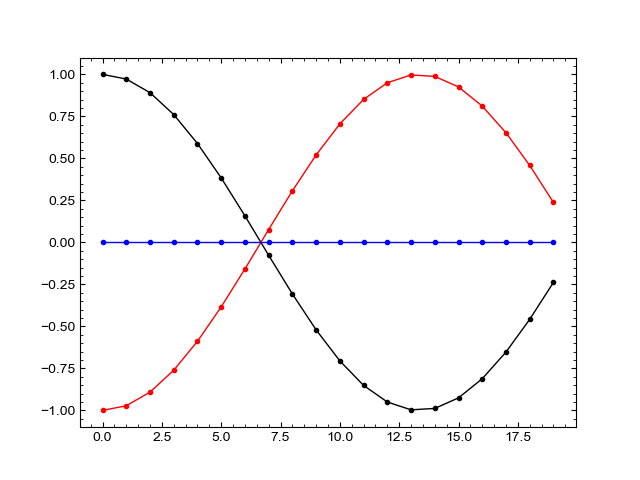

In [105]:
ri = quad.propogate_ray(r0, z=20)
print('ri',ri.shape)

fig, ax = plt.subplots()
for path, s in zip(ri[...,0], r0[...,0]):
    ax.plot(path, ls='-', marker='.')

In [10]:
quad = Element1D(name='Quad', poles=4, length=10, position=1, strength=0.2)
quad

,name,kind,length,strength,calibration
0,Quad,None,10,0.2,None


In [11]:
r0 = xp.array([[1,-1],
               [-1,1],
               [0,0]])
print('r0',r0.shape)

r0 (3, 2)


(2, 2, 20) (3, 2)
ri (3, 20, 2)


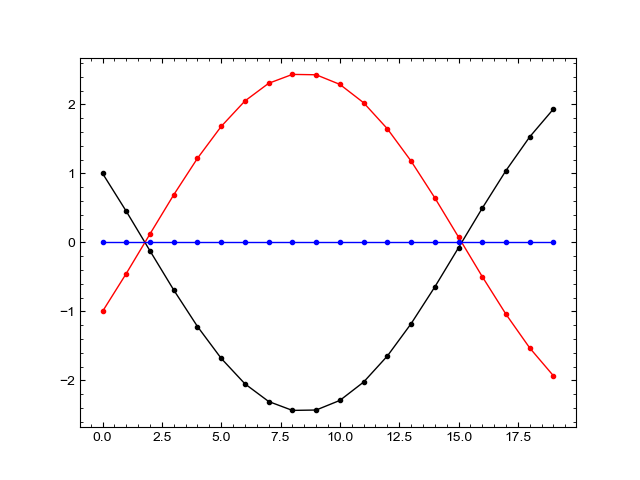

In [12]:
ri = quad.propogate_ray(r0, z=20)
print('ri',ri.shape)

fig, ax = plt.subplots()
for path, s in zip(ri[...,0], r0[...,0]):
    ax.plot(path, ls='-', marker='.')